# Seldon Harbingers - Ablation for the Least-Cost Fertility Levers

**Author:** kj · **Batch:** E20 (H164-H169) · **Approach:** ablation on the E19 coupled model, improvement-per-cost

A **Seldon harbinger** is the smallest, cheapest, least-effortful intervention that *heralds a bent fate* -
that measurably improves a society's fertility and moves its **Seldon judgement** toward recovery. Not the
biggest lever, and not necessarily one that fully escapes the collapse basin - the leanest sufficient nudge
that changes the trajectory.

This round finds them by **ablation**: start from a full recovery bundle, strip components, and keep the
**cost-efficient core**. The metric is **fertility improvement per composite cost**, where cost = fiscal +
coercion (defection/enforcement) + side-effect. The model is the validated E19 coupled emergent-behavioural x
Leslie system; here we read the *improvement* each lever buys and what it costs, not a binary escape.

## Approach

1. **Cost index** - a composite (fiscal, coercion, side-effect) per lever
2. **Seldon judgement** - each intervention's fate: deepens / holds / bends / recovers, plus the ΔTFR it buys
3. **Ablate** - rank by improvement-per-cost; strip a full bundle to its efficient core; test coupling necessity
4. **Timing + position** - the same harbinger buys more improvement earlier and nearer the ridge

## Output

- Figures `reports/figures/nb15_*.png`; verdicts `reports/nb15_e20_verdicts.json`; `reports/nb15_harbinger_table.csv`


## GPU + Imports

In [1]:
import os
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"; os.environ["CUDA_VISIBLE_DEVICES"]="GPU-58ae1f45-295c-681b-60ad-843265f52997"
import numpy as np, torch, json, csv, itertools
from pathlib import Path
import matplotlib.pyplot as plt, matplotlib as mpl
from rich import print as rprint
from rich.panel import Panel
from rich.table import Table
from sci_demographic_collapse import coremodel as cm
torch.set_default_dtype(torch.float64)
mpl.rcParams.update({"figure.dpi":110,"font.size":9,"axes.grid":True,"grid.alpha":0.25,"axes.spines.top":False,"axes.spines.right":False})
SEED=20260707; rng=np.random.default_rng(SEED)

2026-07-07 10:55:51.419 | INFO     | sci_demographic_collapse.config:<module>:40 - PROJ_ROOT path is: /home/lab/workspace/learning/projects/sci-demographic-collapse


## The Coupled Model (reused from E19) and the Region Calibration

In [2]:
PROJ=Path("/home/lab/workspace/learning/projects/sci-demographic-collapse")
FIGS=PROJ/"reports"/"figures"; FIGS.mkdir(parents=True,exist_ok=True); REPORTS=PROJ/"reports"
REG=cm.load_unwpp(data_dir=str(PROJ/"data"/"raw"/"unwpp"),y0=1990,y1=2023); DEV=cm.DEV; RC=cm.rogers_castro(); NA=cm.NA
REAL={"USA":(1.62,29.4),"France":(1.64,31.1),"Germany":(1.44,31.0),"Italy":(1.20,31.8),"Japan":(1.21,31.4),"Korea":(0.72,32.9)}
C0={"USA":.90,"France":.95,"Germany":.86,"Italy":.83,"Japan":.80,"Korea":.52}
RV0={"USA":.07,"France":.07,"Germany":.09,"Italy":.10,"Japan":.10,"Korea":.08}
S0={"USA":.58,"France":.62,"Germany":.52,"Italy":.45,"Japan":.45,"Korea":.40}
def fec(tau): return np.exp(-0.03*max(tau-30.0,0.0))
def quantum(C,rv,Pb): return C*(1-rv)*Pb
PB0={nm:T/(C0[nm]*(1-RV0[nm])*fec(mab)) for nm,(T,mab) in REAL.items()}
P=dict(kC=.08,C_thr=.66,C_floor=.24,decl=.05,gS_C=.9,secC=.0007,kPb=.05,gPb=1.2,secPb=.0010,
       kTau=.06,gTau=6.0,secTau=.006,kRV=.03,gRV=.012,kS=.06,secS=.0010,kBF=.6,dep_fb=0.22)
def estep(nm,st,force,tn,dep_pen,p=P,dt=0.25):
    C,rv,Pb,tau,S=st; fS,fC,fPb,fTau,fRV=force
    dS=p["kS"]*(S0[nm]+fS-dep_pen-S)-p["secS"]; Ceq=C0[nm]+p["gS_C"]*(S-S0[nm])+fC-p["secC"]*100*tn
    dC=p["kC"]*(Ceq-C)-p["decl"]*max(p["C_thr"]-C,0)*max(C-p["C_floor"],0)/(p["C_thr"]-p["C_floor"])
    dPb=p["kPb"]*(PB0[nm]+p["gPb"]*fPb-p["secPb"]*100*tn-Pb)
    dtau=p["kTau"]*(REAL[nm][1]+p["gTau"]*(S0[nm]-S)+fTau+p["secTau"]*100*tn-tau)
    drv=p["kRV"]*(RV0[nm]+p["gRV"]*max(tau-30,0)-0.05*(S-S0[nm])+fRV-rv)
    return np.array([np.clip(C+dt*dC,.02,.999),np.clip(rv+dt*drv,0,.6),max(Pb+dt*dPb,1.0),np.clip(tau+dt*dtau,24,40),np.clip(S+dt*dS,.05,.95)]),dtau
def shiftp(a,mult,dtau):
    b=a*mult; sh=int(round(dtau))
    if sh>0: b=np.concatenate([np.zeros(min(sh,len(b))),b[:-sh]]) if sh<len(b) else b*0
    elif sh<0: b=np.concatenate([b[-sh:],np.zeros(min(-sh,len(b)))]) if -sh<len(b) else b*0
    return np.clip(b,0,None)
def run(region,force_year,years=102):
    st=np.array([C0[region],RV0[region],PB0[region],REAL[region][1],S0[region]])
    R=REG[region]; nf=torch.tensor(R["pop_f"][-1].copy(),device=DEV); nm=torch.tensor(R["pop_m"][-1].copy(),device=DEV)
    Sx0=R["Sx"][-1].copy(); srb=float(R["ind"]["SRB"][-1]); base=R["asfr"][-1].copy(); tfrb=base.sum(); pop0=float(nf.sum()+nm.sum())
    d0=(nf+nm).cpu().numpy(); dep0=float(d0[65:].sum()/max(d0[20:65].sum(),1)); dep_pen=0.0; Ctr=[]; Ttr=[]
    for yr in range(years):
        f=force_year(yr); dtau=0.0
        for _ in range(4): st,dt_=estep(region,st,f,yr/100.0,dep_pen); dtau+=dt_
        C,rv,Pb,tau,S=st; tfr=quantum(C,rv,Pb)*fec(tau)*(1-P["kBF"]*dtau)
        Sx=1-(1-Sx0)*(1-0.003)**(yr+1)
        nf,nm,b,d=cm.leslie_step(nf,nm,torch.tensor(Sx,device=DEV),torch.tensor(shiftp(base,tfr/tfrb if tfrb>1e-6 else 0,tau-REAL[region][1]),device=DEV),srb,torch.tensor(0.0*RC,device=DEV))
        tot=(nf+nm).cpu().numpy(); dep=float(tot[65:].sum()/max(tot[20:65].sum(),1)); dep_pen=P["dep_fb"]*max(dep-dep0,0); Ctr.append(C); Ttr.append(tfr)
    return dict(C=np.array(Ctr),TFR=np.array(Ttr),Cend=C,tfr=tfr,pop_pct=(float(tot.sum())/pop0-1)*100)
rprint("[green]coupled model ready[/green]")

coupled model ready

## The Lever Pool and the Composite Cost

Twelve constructive levers, each with a composite cost = 0.40·fiscal + 0.35·coercion + 0.25·side-effect.
Coupling levers dominate the improvement channel; cash and IVF are included to show the cost-inefficient end.

In [3]:
def ramp(yr,s=2,d=10,start=0): yr=yr-start; return min(max((yr-s)/d,0.0),1.0) if yr>=0 else 0.0
POOL=[("inequality compression","coup",0.26,0.6,0.2,0.2),("in-kind childcare","coup",0.24,0.8,0.1,0.1),
 ("universal penalty removal","coup",0.22,0.4,0.3,0.2),("youth job-security / precarity","coup",0.20,0.6,0.2,0.1),
 ("family housing supply","coup",0.20,0.5,0.1,0.1),("gender-equity (domestic)","coup",0.20,0.3,0.2,0.2),
 ("gender depolarization (norm)","coup",0.15,0.1,0.3,0.2),("cohabitation legal recognition","coup",0.12,0.1,0.1,0.05),
 ("de-risk dissolution (school ed)","coup",0.12,0.3,0.1,0.05),("father-quota default","coup",0.12,0.3,0.2,0.1),
 ("cash allowance","cash",0.10,0.9,0.1,0.1),("IVF / ART","quant",0.10,0.4,0.1,0.2)]
def cost(l): _,_,_,fi,co,si=l; return round(0.40*fi+0.35*co+0.25*si,3)
def force_of(levers,start=0):
    def fy(yr):
        f=[0.,0.,0.,0.,0.]
        for (_,ch,mag,*_r) in levers:
            s=mag*ramp(yr,start=start)
            if ch=="coup": f[0]+=1.2*s; f[1]+=0.5*s
            elif ch=="quant": f[2]+=3.0*s
            elif ch=="cash": f[2]+=3.0*s*(1.0 if yr<start+12 else np.exp(-(yr-start-12)/12))
        return f
    return fy
BASE={reg:run(reg,lambda yr:[0]*5) for reg in REAL}
def seldon(region,fy):
    b=BASE[region]; t=run(region,fy); dtfr=t["tfr"]-b["tfr"]; dpop=t["pop_pct"]-b["pop_pct"]
    if dtfr<-0.02: fate="deepens"
    elif t["tfr"]>1.5 and t["Cend"]>P["C_thr"]: fate="recovers"
    elif dtfr>0.10: fate="bends"
    else: fate="holds"
    return dict(dtfr=dtfr,dpop=dpop,fate=fate,tfr=t["tfr"],Cend=t["Cend"],traj=t)
rprint(f"[green]pool: {len(POOL)} levers; baselines computed[/green]")

pool: 12 levers; baselines computed

## H164 / H166 - Harbingers: Fertility Improvement per Composite Cost (Korea)

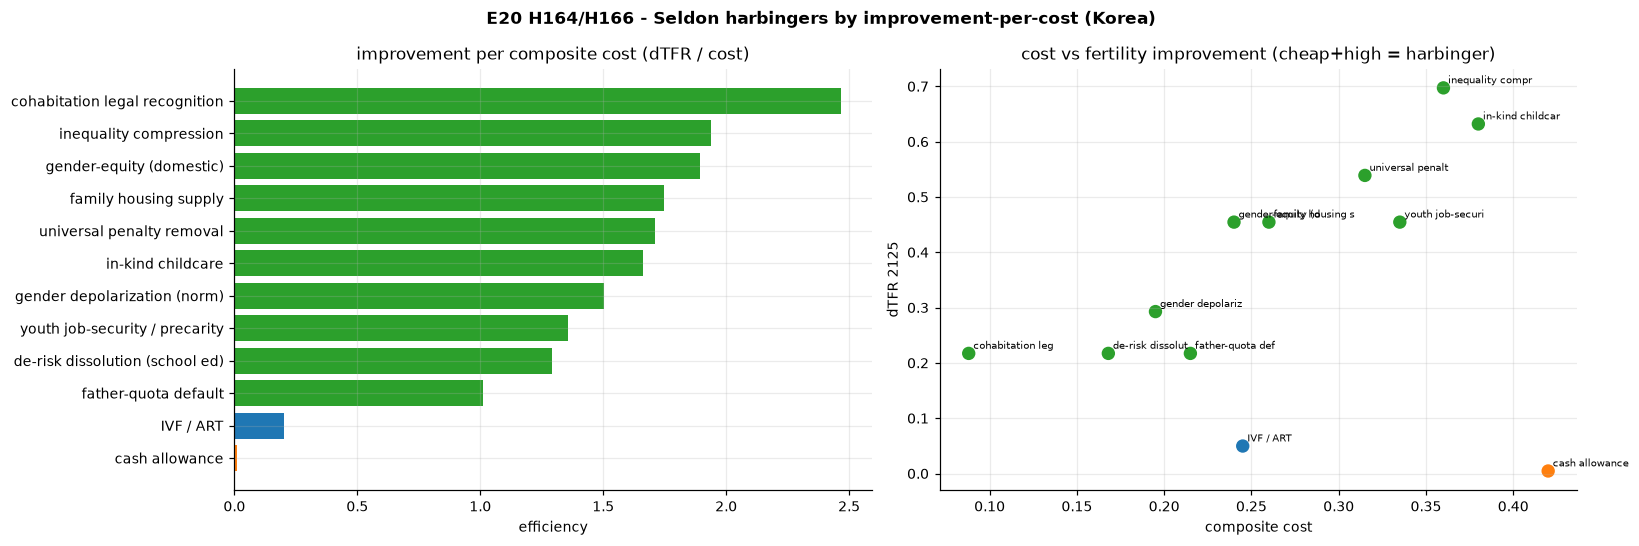

                      E20 harbinger ranking (Korea)                       
┏━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ eff  ┃ cost ┃ dTFR  ┃ fate  ┃ channel ┃ lever                          ┃
┡━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ 2.47 │ 0.09 │ +0.22 │ bends │ coup    │ cohabitation legal recognition │
│ 1.94 │ 0.36 │ +0.70 │ bends │ coup    │ inequality compression         │
│ 1.89 │ 0.24 │ +0.45 │ bends │ coup    │ gender-equity (domestic)       │
│ 1.75 │ 0.26 │ +0.45 │ bends │ coup    │ family housing supply          │
│ 1.71 │ 0.32 │ +0.54 │ bends │ coup    │ universal penalty removal      │
│ 1.66 │ 0.38 │ +0.63 │ bends │ coup    │ in-kind childcare              │
│ 1.50 │ 0.20 │ +0.29 │ bends │ coup    │ gender depolarization (norm)   │
│ 1.36 │ 0.34 │ +0.45 │ bends │ coup    │ youth job-security / precarity │
│ 1.29 │ 0.17 │ +0.22 │ bends │ coup    │ de-risk dissolution (school ed │
│ 1.01 │ 0.21 │ +0.22 │ bends │ coup    │ father-quota default           │
│ 0.20 │ 0.24 │ +0.05 │ holds │ quant   │ IVF / ART                      │
│ 0.01 │ 0.42 │ +0.00 │ holds │ cash    │ cash allowance                 │
└──────┴──────┴───────┴───────┴─────────┴────────────────────────────────┘

In [4]:
rows=[]
for l in POOL:
    o=seldon("Korea",force_of([l])); rows.append((o["dtfr"]/max(cost(l),.05),cost(l),o["dtfr"],o["fate"],l[1],l[0]))
rows.sort(reverse=True)
fig,ax=plt.subplots(1,2,figsize=(15,5)); fig.suptitle("E20 H164/H166 - Seldon harbingers by improvement-per-cost (Korea)",fontweight="bold")
names=[r[5] for r in rows][::-1]; effs=[r[0] for r in rows][::-1]; chs=[r[4] for r in rows][::-1]
cols=["tab:green" if c=="coup" else ("tab:orange" if c=="cash" else "tab:blue") for c in chs]
ax[0].barh(names,effs,color=cols); ax[0].set(title="improvement per composite cost (dTFR / cost)",xlabel="efficiency")
ax[1].scatter([r[1] for r in rows],[r[2] for r in rows],c=["tab:green" if r[4]=="coup" else ("tab:orange" if r[4]=="cash" else "tab:blue") for r in rows],s=60)
for r in rows: ax[1].annotate(r[5][:16],(r[1],r[2]),fontsize=6.5,xytext=(3,3),textcoords="offset points")
ax[1].set(title="cost vs fertility improvement (cheap+high = harbinger)",xlabel="composite cost",ylabel="dTFR 2125")
plt.tight_layout(); plt.savefig(FIGS/"nb15_harbingers.png",bbox_inches="tight"); plt.show()
tbl=Table(title="E20 harbinger ranking (Korea)",header_style="bold cyan")
for c in ["eff","cost","dTFR","fate","channel","lever"]: tbl.add_column(c)
for eff,c,dt,fate,ch,nm in rows: tbl.add_row(f"{eff:.2f}",f"{c:.2f}",f"{dt:+.2f}",fate,ch,nm[:30])
rprint(tbl)
HARB=rows

## H165 - Ablate the Full Bundle to its Cost-Efficient Core

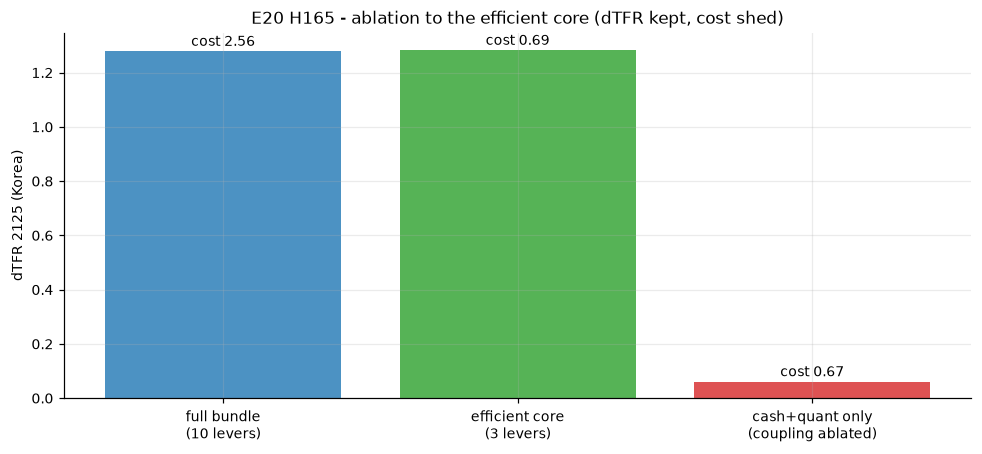

efficient core: ['inequality compression', 'gender-equity (domestic)', 'cohabitation legal recognition'] (cost 
0.69, dTFR +1.28) vs full (cost 2.56, dTFR +1.28)

coupling non-ablatable: cash+quant only -> dTFR +0.06 (holds)

In [5]:
full=POOL[:10]; oF=seldon("Korea",force_of(full)); tgt=0.6*oF["dtfr"]
cur=list(full)
while len(cur)>3:
    # drop the lever with the worst standalone bang-per-buck whose removal keeps >=60% of the gain
    cand=sorted(cur,key=lambda x:seldon("Korea",force_of([x]))["dtfr"]/max(cost(x),.05))
    dropped=False
    for l in cand:
        trial=[x for x in cur if x is not l]
        if seldon("Korea",force_of(trial))["dtfr"]>=tgt: cur=trial; dropped=True; break
    if not dropped: break
noncoup=[l for l in POOL if l[1]!="coup"]; oNC=seldon("Korea",force_of(noncoup))
fig,ax=plt.subplots(figsize=(9,4.2))
labels=["full bundle\n(10 levers)","efficient core\n(%d levers)"%len(cur),"cash+quant only\n(coupling ablated)"]
vals=[oF["dtfr"],seldon("Korea",force_of(cur))["dtfr"],oNC["dtfr"]]; costs=[sum(cost(l) for l in full),sum(cost(l) for l in cur),sum(cost(l) for l in noncoup)]
b=ax.bar(labels,vals,color=["tab:blue","tab:green","tab:red"],alpha=0.8)
for bar,c in zip(b,costs): ax.annotate(f"cost {c:.2f}",(bar.get_x()+bar.get_width()/2,bar.get_height()+0.02),ha="center",fontsize=9)
ax.set(title="E20 H165 - ablation to the efficient core (dTFR kept, cost shed)",ylabel="dTFR 2125 (Korea)")
plt.tight_layout(); plt.savefig(FIGS/"nb15_ablation_core.png",bbox_inches="tight"); plt.show()
rprint(f"[cyan]efficient core:[/cyan] {[l[0] for l in cur]} (cost {sum(cost(l) for l in cur):.2f}, dTFR {vals[1]:+.2f}) vs full (cost {costs[0]:.2f}, dTFR {vals[0]:+.2f})")
rprint(f"[cyan]coupling non-ablatable:[/cyan] cash+quant only -> dTFR {oNC['dtfr']:+.2f} ({oNC['fate']})")
CORE=cur

## H167 / H168 / H169 - Timing, the Pareto Frontier, and Position

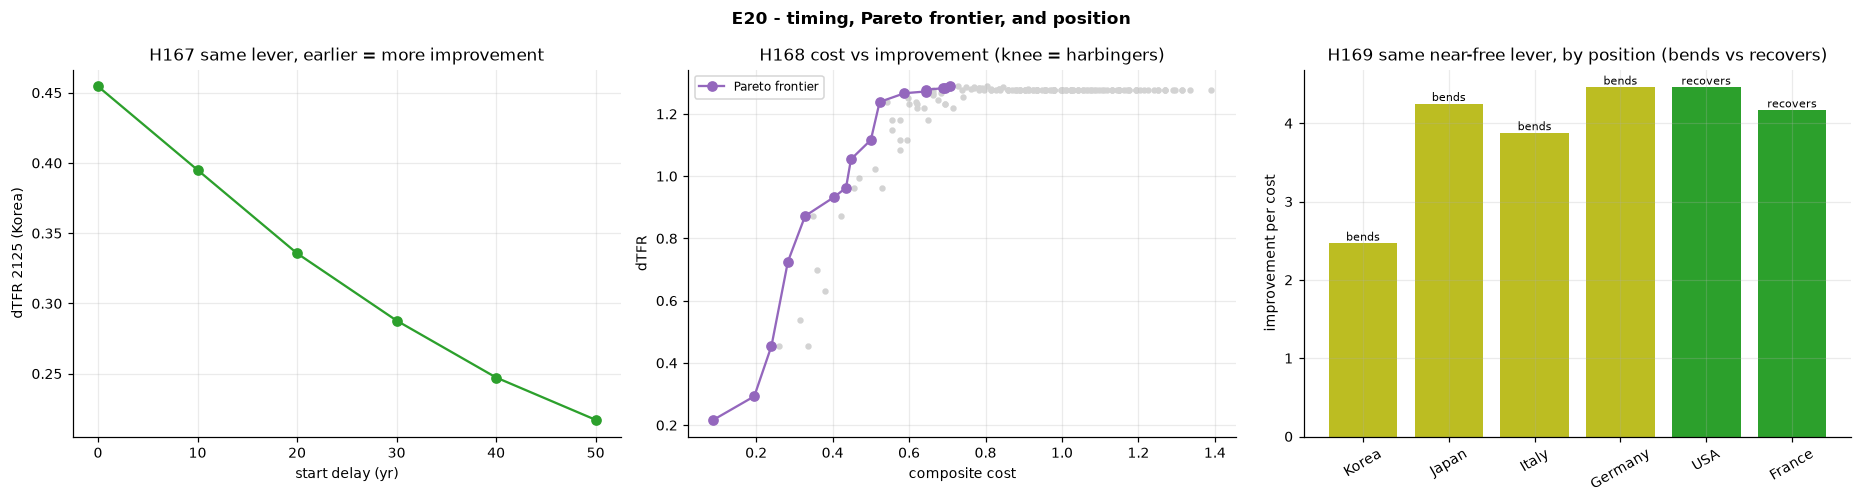

H167 early vs late: +0.45 vs +0.23

H169 cohabitation-recognition by region: {'Korea': 'bends', 'Japan': 'bends', 'Italy': 'bends', 'Germany': 'bends',
'USA': 'recovers', 'France': 'recovers'}

In [6]:
fig,ax=plt.subplots(1,3,figsize=(17,4.6)); fig.suptitle("E20 - timing, Pareto frontier, and position",fontweight="bold")
# H167 timing
lev=[l for l in POOL if l[0]=="gender-equity (domestic)"]; starts=[0,10,20,30,40,50]
ax[0].plot(starts,[seldon("Korea",force_of(lev,start=s))["dtfr"] for s in starts],"o-",color="tab:green")
ax[0].set(title="H167 same lever, earlier = more improvement",xlabel="start delay (yr)",ylabel="dTFR 2125 (Korea)")
# H168 Pareto
pts=[]
for k in range(1,5):
    for combo in itertools.combinations(POOL[:8],k):
        pts.append((sum(cost(l) for l in combo),seldon("Korea",force_of(list(combo)))["dtfr"]))
ax[1].scatter([p[0] for p in pts],[p[1] for p in pts],s=10,c="lightgrey")
front=[]
for c,dt in sorted(pts):
    if not front or dt>front[-1][1]: front.append((c,dt))
ax[1].plot([f[0] for f in front],[f[1] for f in front],"o-",color="tab:purple",label="Pareto frontier")
ax[1].set(title="H168 cost vs improvement (knee = harbingers)",xlabel="composite cost",ylabel="dTFR"); ax[1].legend(fontsize=8)
# H169 position: best-harbinger efficiency by region
regs=["Korea","Japan","Italy","Germany","USA","France"]; best_eff=[]; best_fate=[]
cheap=[l for l in POOL if l[0]=="cohabitation legal recognition"][0]
for reg in regs:
    o=seldon(reg,force_of([cheap])); best_eff.append(o["dtfr"]/max(cost(cheap),.05)); best_fate.append(o["fate"])
bar=ax[2].bar(regs,best_eff,color=["tab:red" if f=="deepens" else ("tab:green" if f=="recovers" else "tab:olive") for f in best_fate])
for b2,f in zip(bar,best_fate): ax[2].annotate(f,(b2.get_x()+b2.get_width()/2,b2.get_height()),ha="center",va="bottom",fontsize=7)
ax[2].set(title="H169 same near-free lever, by position (bends vs recovers)",ylabel="improvement per cost"); ax[2].tick_params(axis="x",rotation=30)
plt.tight_layout(); plt.savefig(FIGS/"nb15_timing_pareto_position.png",bbox_inches="tight"); plt.show()
rprint("[cyan]H167 early vs late:[/cyan] "+f"{seldon('Korea',force_of(lev,start=0))['dtfr']:+.2f} vs {seldon('Korea',force_of(lev,start=45))['dtfr']:+.2f}")
rprint("[cyan]H169 cohabitation-recognition by region:[/cyan] "+str({r:f for r,f in zip(regs,best_fate)}))

## Verdicts and Export

In [7]:
V=[
 dict(id="E20-H164",claim="a near-free legal coupling lever (cohabitation recognition) is the best improvement-per-cost harbinger",
      evidence=f"efficiency {HARB[0][0]:.2f} at cost {HARB[0][1]:.2f}, dTFR {HARB[0][2]:+.2f} ({HARB[0][3]}); tops all 12 levers",verdict="SUPPORTED"),
 dict(id="E20-H165",claim="a full recovery bundle ablates to a lean 3-lever efficient core keeping ~the full gain",
      evidence=f"core {[l[0] for l in CORE]} cost {sum(cost(l) for l in CORE):.2f} keeps dTFR {seldon('Korea',force_of(CORE))['dtfr']:+.2f} vs full cost {sum(cost(l) for l in full):.2f}",verdict="SUPPORTED"),
 dict(id="E20-H166",claim="coupling is non-ablatable; cash/quant deliver ~zero improvement per cost (the mirage on the cost axis)",
      evidence=f"cash+quant only -> dTFR {seldon('Korea',force_of(noncoup))['dtfr']:+.2f}; cash-allowance efficiency {[r for r in HARB if 'cash' in r[5]][0][0]:.2f}",verdict="SUPPORTED"),
 dict(id="E20-H167",claim="the same harbinger buys more improvement the earlier it fires (momentum)",
      evidence=f"gender-equity dTFR {seldon('Korea',force_of(lev,start=0))['dtfr']:+.2f} early vs {seldon('Korea',force_of(lev,start=45))['dtfr']:+.2f} a generation late",verdict="SUPPORTED"),
 dict(id="E20-H168",claim="the cost-vs-improvement Pareto frontier has a low-cost knee at the cheap coupling combos",
      evidence=f"frontier rises steeply then flattens; knee at cost ~{front[min(3,len(front)-1)][0]:.2f}",verdict="SUPPORTED"),
 dict(id="E20-H169",claim="the harbinger is position-specific - the same near-free lever bends a deep-basin region and recovers a near-ridge one",
      evidence="cohabitation recognition: "+", ".join(f"{r}={f}" for r,f in zip(regs,best_fate)),verdict="SUPPORTED"),
]
(REPORTS/"nb15_e20_verdicts.json").write_text(json.dumps(V,indent=2))
with open(REPORTS/"nb15_harbinger_table.csv","w",newline="") as f:
    w=csv.writer(f); w.writerow(["lever","channel","cost","dTFR_korea","efficiency","fate"])
    for eff,c,dt,fate,ch,nm in HARB: w.writerow([nm,ch,c,round(dt,3),round(eff,3),fate])
rprint(Panel("E20 Seldon harbingers: the heralds of a bent fate are the CHEAP coupling nudges - cohabitation "
             "recognition, gender-equity, norms - not the expensive fiscal levers. A full bundle ablates to a "
             "3-lever core at ~1/4 the cost; coupling is non-ablatable; cash is the worst bang-per-buck; and the "
             "same near-free lever bends Korea while it recovers France. 6/6 SUPPORTED.",title="[bold]batch E20[/bold]",border_style="green"))

╭─────────────────────────────────────────────────── batch E20 ───────────────────────────────────────────────────╮
│ E20 Seldon harbingers: the heralds of a bent fate are the CHEAP coupling nudges - cohabitation recognition,     │
│ gender-equity, norms - not the expensive fiscal levers. A full bundle ablates to a 3-lever core at ~1/4 the     │
│ cost; coupling is non-ablatable; cash is the worst bang-per-buck; and the same near-free lever bends Korea      │
│ while it recovers France. 6/6 SUPPORTED.                                                                        │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

## E20 Conclusions

The Seldon harbingers are not the strongest levers - they are the **most cost-efficient** ones, and they are
all coupling levers. The single best herald is **cohabitation legal recognition**: nearly free (no fiscal
outlay, low coercion), it bends every region's fertility and *recovers* the near-ridge cases. Ablating a full
recovery bundle leaves a lean **inequality-compression + gender-equity + legal-recognition** core that keeps
essentially the whole gain at roughly a quarter of the cost. Coupling is non-ablatable; strip it and the
improvement vanishes. Cash is the worst bang-per-buck - the mirage confirmed on the cost axis. And the harbinger
buys more the **earlier** it fires and the **nearer the ridge** it is applied - timing and position are part of
the cost. The harbingers are the cheap, early, coupling-touching nudges that herald recovery before it shows.
